In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import anndata
from glob import glob
import os
import scanpy as sc
import logging
import warnings
import statsmodels.api as sm
import statsmodels.formula.api as smf
warnings.filterwarnings('ignore')
sns.set(font_scale=1.8, style = "ticks")

# Spatial transcriptomics - ABC dataset

In [ ]:
from pathlib import Path
from abc_atlas_access.abc_atlas_cache.abc_project_cache import AbcProjectCache

download_base = Path("Merfish_ABC_data")
abc_cache = AbcProjectCache.from_cache_dir(download_base)

abc_cache.current_manifest
abc_cache.list_data_files("WMB-10Xv3")

abc_cache.get_data_path(directory="WMB-10Xv3", file_name="WMB-10Xv3-HY/log2")

WMB-10Xv3-HY-log2.h5ad:   9%|▉         | 661M/7.25G [00:41<06:13, 17.6MMB/s]     

KeyboardInterrupt: 

In [17]:
abc_cache.current_manifest

'releases/20250131/manifest.json'

In [7]:
file = abc_cache.get_data_path(directory="WMB-10Xv3", file_name="WMB-10Xv3-HY/log2")
adata = anndata.read_h5ad(file, backed="r+")
print(adata)

AnnData object with n_obs × n_vars = 162869 × 32285 backed at '/Users/caom/Documents/negative_parental_switch/NPW_transcripts/transcriptormics _merfish/Merfish_ABC_data/expression_matrices/WMB-10Xv3/20230630/WMB-10Xv3-HY-log2.h5ad'
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label'
    var: 'gene_symbol'
    uns: 'normalization', 'parent', 'parent_layer', 'parent_rows'


In [3]:
cell = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850",
    file_name="cell_metadata_with_cluster_annotation",
)
cell.rename(
    columns={"x": "x_section", "y": "y_section", "z": "z_section"}, inplace=True
)
cell.set_index("cell_label", inplace=True)
cell.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,neurotransmitter,class,subclass,supertype,cluster,neurotransmitter_color,class_color,subclass_color,supertype_color,cluster_color
cell_label,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,NaN,04 DG-IMN Glut,038 DG-PIR Ex IMN,0141 DG-PIR Ex IMN_2,0515 DG-PIR Ex IMN_2,#666666,#16f2f2,#3D53CC,#CC7A3D,#73FFBF
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,Glut,23 P Glut,235 PG-TRN-LRN Fat2 Glut,0953 PG-TRN-LRN Fat2 Glut_1,4199 PG-TRN-LRN Fat2 Glut_1,#2B93DF,#6b5ca5,#9B7ACC,#990041,#663D63


In [4]:
reconstructed_coords = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850-CCF",
    file_name="reconstructed_coordinates",
    dtype={"cell_label": str},
)
reconstructed_coords.rename(
    columns={"x": "x_reconstructed", "y": "y_reconstructed", "z": "z_reconstructed"},
    inplace=True,
)
reconstructed_coords.set_index("cell_label", inplace=True)
cell_joined = cell.join(reconstructed_coords, how="inner")

In [5]:
ccf_coords = abc_cache.get_metadata_dataframe(
    directory="MERFISH-C57BL6J-638850-CCF",
    file_name="ccf_coordinates",
    dtype={"cell_label": str},
)
ccf_coords.rename(columns={"x": "x_ccf", "y": "y_ccf", "z": "z_ccf"}, inplace=True)
ccf_coords.drop(["parcellation_index"], axis=1, inplace=True)
ccf_coords.set_index("cell_label", inplace=True)
cell_joined = cell_joined.join(ccf_coords, how="inner")

In [6]:
parcellation_annotation = abc_cache.get_metadata_dataframe(
    directory="Allen-CCF-2020",
    file_name="parcellation_to_parcellation_term_membership_acronym",
)
parcellation_annotation.set_index("parcellation_index", inplace=True)
parcellation_annotation.columns = [
    "parcellation_%s" % x for x in parcellation_annotation.columns
]
parcellation_annotation.head(5)

,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure
parcellation_index,,,,,
0,unassigned,unassigned,unassigned,unassigned,unassigned
1,brain,grey,HY,TMv,TMv
2,brain,grey,Isocortex,SSp-m,SSp-m6b
5,brain,fiber tracts,lfbs,cst,int
6,brain,grey,P,PSV,PSV


In [7]:
parcellation_color = abc_cache.get_metadata_dataframe(
    directory="Allen-CCF-2020",
    file_name="parcellation_to_parcellation_term_membership_color",
)
parcellation_color.set_index("parcellation_index", inplace=True)
parcellation_color.columns = ["parcellation_%s" % x for x in parcellation_color.columns]
parcellation_color.head(5)

,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
parcellation_index,,,,,
0,#000000,#000000,#000000,#000000,#000000
1,#FFFFFF,#BFDAE3,#E64438,#FF4C3E,#FF4C3E
2,#FFFFFF,#BFDAE3,#70FF71,#188064,#188064
5,#FFFFFF,#CCCCCC,#CCCCCC,#CCCCCC,#CCCCCC
6,#FFFFFF,#BFDAE3,#FF9B88,#FFAE6F,#FFAE6F


In [8]:
cell_joined = cell_joined.join(parcellation_annotation, on="parcellation_index")
cell_joined = cell_joined.join(parcellation_color, on="parcellation_index")
cell_joined.head(5)

,brain_section_label,cluster_alias,average_correlation_score,feature_matrix_label,donor_label,donor_genotype,donor_sex,x_section,y_section,z_section,...,parcellation_organ,parcellation_category,parcellation_division,parcellation_structure,parcellation_substructure,parcellation_organ_color,parcellation_category_color,parcellation_division_color,parcellation_structure_color,parcellation_substructure_color
cell_label,,,,,,,,,,,,,,,,,,,,,
1019171907102340387-1,C57BL6J-638850.37,1408,0.596276,C57BL6J-638850,C57BL6J-638850,wt/wt,M,7.226245,4.148963,6.6,...,brain,grey,HPF,DG,DG-po,#FFFFFF,#BFDAE3,#7ED04B,#7ED04B,#7ED04B
1104095349101460194-1,C57BL6J-638850.26,4218,0.641180,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.064889,7.309543,4.2,...,brain,grey,P,TRN,TRN,#FFFFFF,#BFDAE3,#FF9B88,#FFBA86,#FFBA86
1017092617101450577,C57BL6J-638850.25,4218,0.763531,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.792921,8.189973,4.0,...,brain,grey,P,P-unassigned,P-unassigned,#FFFFFF,#BFDAE3,#FF9B88,#FF9B88,#FF9B88
1018093344101130233,C57BL6J-638850.13,4218,0.558073,C57BL6J-638850,C57BL6J-638850,wt/wt,M,3.195950,5.868655,2.4,...,brain,fiber tracts,cbf,arb,arb,#FFFFFF,#CCCCCC,#CCCCCC,#CCCCCC,#CCCCCC
1019171912201610094,C57BL6J-638850.27,4218,0.591009,C57BL6J-638850,C57BL6J-638850,wt/wt,M,5.635732,7.995842,4.4,...,brain,grey,P,P-unassigned,P-unassigned,#FFFFFF,#BFDAE3,#FF9B88,#FF9B88,#FF9B88


In [18]:
imputed_h5ad_path = abc_cache.get_data_path(
    "MERFISH-C57BL6J-638850-imputed", "C57BL6J-638850-imputed/log2"
)
adata = anndata.read_h5ad(imputed_h5ad_path, backed="r+")

C57BL6J-638850-imputed-log2.h5ad: 100%|██████████| 50.2G/50.2G [1:11:05<00:00, 11.8MMB/s]   


In [19]:
print(adata)

AnnData object with n_obs × n_vars = 4334174 × 8460 backed at '/Users/caom/Documents/negative_parental_switch/NPW_transcripts/transcriptormics _merfish/Merfish_ABC_data/expression_matrices/MERFISH-C57BL6J-638850-imputed/20240831/C57BL6J-638850-imputed-log2.h5ad'
    obs: 'brain_section_label'
    var: 'gene_symbol'


In [111]:
mpoa_list = ["MPO", "MPN", "PD", "ADP"]

filter_cells = cell_joined[
    cell_joined["parcellation_substructure"].isin(mpoa_list)
].index

In [112]:
adata.strings_to_categoricals()
filtered_adata = adata[filter_cells, :].copy(
    filename="filtered_cells.h5ad"
)  # Save filtered cells)

In [2]:
# read saved adata
import anndata

filtered_adata = anndata.read_h5ad("Merfish_ABC_data/filtered_cells.h5ad", backed="r+")

In [3]:
gene_list = [
    "Npy1r",
    "Npy2r",
    "Hcn1",
    "Hcn2",
    "Esr1",
    "Pgr",
]
filtered_df = filtered_adata[:, filtered_adata.var["gene_symbol"].isin(gene_list)]

In [4]:
gene_dict = pd.Series(
    filtered_df.var.index, index=filtered_df.var.gene_symbol
).to_dict()

In [21]:
filtered_df.to_df().head(5)


# percentage of colocalization
def colocalization(df, gene_list, threshold=1):
    ensemblr = [gene_dict[gene] for gene in gene_list]
    colocalized = (df.loc[:, ensemblr] >= threshold).all(axis=1)
    colocalized_percentage = colocalized.mean() * 100

    return colocalized_percentage


def conditioned_localization(df, either_lists, and_list, threshold=1):
    eithers = []
    for either_list in either_lists:
        ensemblr = [gene_dict[gene] for gene in either_list]
        either = (df.loc[:, ensemblr] >= threshold).any(axis=1)
        eithers.append(either)

    ensemblr_and = [gene_dict[gene] for gene in and_list]
    and_positive = (df.loc[:, ensemblr_and] >= threshold).all(axis=1)

    # Combine both conditions with AND
    condition = eithers[0] & eithers[1] & and_positive
    # Calculate percentage of cells where both conditions are true
    colocalization_percentage = condition.mean() * 100
    return colocalization_percentage


npy_either_list = ["Npy1r", "Npy2r"]
hcn_either_list = ["Hcn1", "Hcn2"]

and_list = ["Esr1", "Pgr"]


colocalization_results = colocalization(
    filtered_df.to_df().copy(), ["Npy1r", "Esr1", "Pgr", "Hcn1"]
)
cond_colocalization_results = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], and_list
)

npyr_and_hcn = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], []
)
npyr_and_hcn = pd.DataFrame({
    "gene": "Npy1/2r + HCN1/2",
    "threshold":1,
    "percentage": [npyr_and_hcn]
})
npyr_and_hcn_2 = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], [], threshold=2
)

npyr_and_hcn_2 = pd.DataFrame({
    "gene": "Npy1/2r + HCN1/2",
    "threshold": 2,
    "percentage": [npyr_and_hcn_2]
})

npyr_and_hcn_3 = conditioned_localization(
    filtered_df.to_df().copy(), [npy_either_list, hcn_either_list], [], threshold=3
)

npyr_and_hcn_3 = pd.DataFrame({
    "gene": "Npy1/2r + HCN1/2",
    "threshold": 3,
    "percentage": [npyr_and_hcn_3]
})
npyr_and_hcns = pd.concat([npyr_and_hcn, npyr_and_hcn_2, npyr_and_hcn_3], ignore_index=True)
print("Colocalization percentage:", colocalization_results)
print("Conditioned colocalization percentage:", cond_colocalization_results)
print("Conditioned colocalization with NPY and HCN:", npyr_and_hcn)

Colocalization percentage: 38.82066600287642
Conditioned colocalization percentage: 46.66445403252572
Conditioned colocalization with NPY and HCN:                gene  threshold  percentage
0  Npy1/2r + HCN1/2          1   55.017148


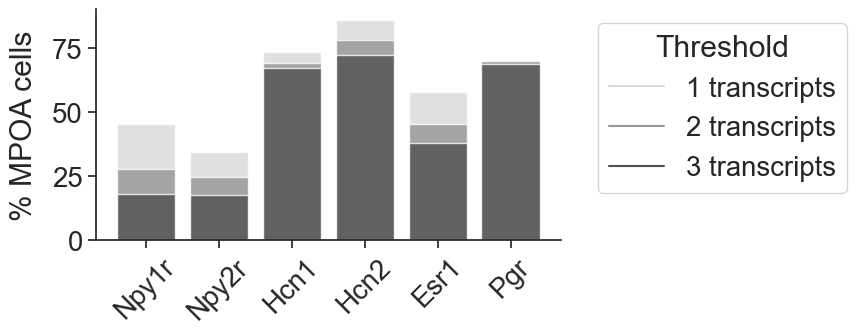

In [22]:
def obtain_percentage_with_different_thresholds(df, gene_list, thresholds):
    percentages = pd.DataFrame(columns=["gene", "threshold", "percentage"])
    for gene in gene_list:
        for threshold in thresholds:
            percentage = colocalization(df, [gene], threshold)
            percentages = pd.concat(
                [
                    percentages,
                    pd.DataFrame(
                        {
                            "gene": [gene],
                            "threshold": [threshold],
                            "percentage": [percentage],
                        }
                    ),
                ],
                ignore_index=True,
            )
    return percentages


thresholds = [1, 2, 3]
gene_list = ["Npy1r", "Npy2r", "Hcn1", "Hcn2",  "Esr1", "Pgr"]
percentages = obtain_percentage_with_different_thresholds(
    filtered_df.to_df().copy(), gene_list, thresholds
)


plt.subplots(figsize=(6, 3))


plt.bar(
    percentages["gene"],
    percentages["percentage"],
    color=sns.color_palette("Grays", n_colors=len(thresholds)),
    alpha=0.8,
)

sns.despine()
# legend
for t in thresholds:
    plt.plot([], [], color=sns.color_palette("Grays", n_colors=len(thresholds))[t-1], label=f"{t} transcripts")
    
plt.legend(
    title="Threshold",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.ylabel("% MPOA cells", labelpad=10)
plt.xticks(rotation=45)
plt.savefig("output_figures/percentage_expression_thresholds.pdf", bbox_inches='tight', dpi=300, transparent=True)

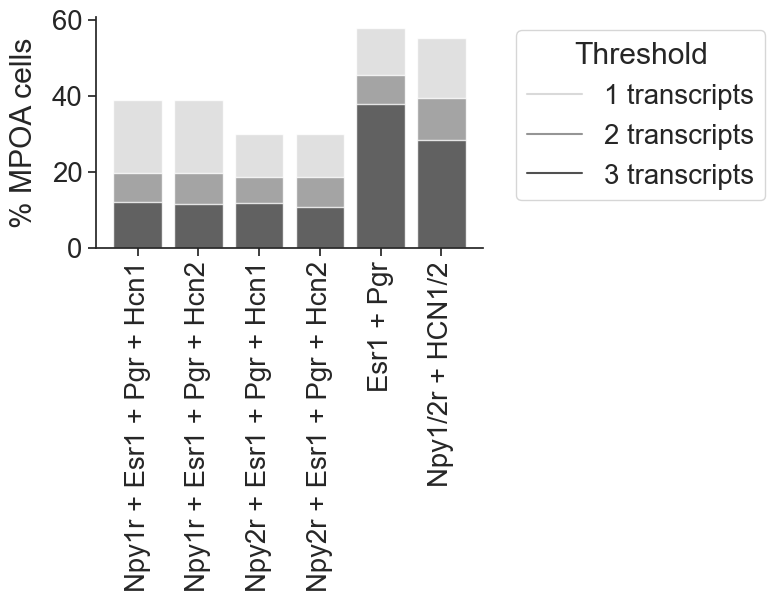

In [23]:
def colocalization_with_thresholds(df, gene_list, thresholds):
    results = pd.DataFrame(columns=["gene", "percentage", 'threshold'])
    for threshold in thresholds:
        colocalization_percentage = colocalization(df, gene_list, threshold)
        combination_name = " + ".join(gene_list)
        results = pd.concat(
            [
                results,
                pd.DataFrame(
                    {
                        "gene": [combination_name],
                        "percentage": [colocalization_percentage],
                        'threshold': [threshold]
                    }
                ),
            ],
            ignore_index=True,
        )
    return results

npy1r_pgr_esr1_hcn1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy1r", "Esr1", "Pgr", "Hcn1"], thresholds)
npy1r_pgr_esr1_hcn2 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy1r", "Esr1", "Pgr", "Hcn2"], thresholds)
npy2r_pgr_esr1_hcn1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy2r", "Esr1", "Pgr", "Hcn1"], thresholds)
npy2r_pgr_esr1_hcn2 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Npy2r", "Esr1", "Pgr", "Hcn2"], thresholds)

pgr_esr1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Esr1", "Pgr"], thresholds)
# pgr_esr1_hcn1 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Esr1", "Pgr", "Hcn1"], thresholds)
# pgr_esr1_hcn2 = colocalization_with_thresholds(filtered_df.to_df().copy(), ["Esr1", "Pgr", "Hcn2"], thresholds)


colocalization_results = pd.concat([
    npy1r_pgr_esr1_hcn1,
    npy1r_pgr_esr1_hcn2,
    npy2r_pgr_esr1_hcn1,
    npy2r_pgr_esr1_hcn2,
    pgr_esr1,
    npyr_and_hcns,
    # pgr_esr1_hcn1,
    # pgr_esr1_hcn2
], ignore_index=True)


plt.subplots(figsize=(5, 3))
plt.bar(
    colocalization_results["gene"],
    colocalization_results["percentage"],
    color=sns.color_palette("Grays", n_colors=len(thresholds)),
    alpha=0.8,
)

for t in thresholds:
    plt.plot([], [], color=sns.color_palette("Grays", n_colors=len(thresholds))[t-1], label=f"{t} transcripts")
    
plt.legend(
    title="Threshold",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)
plt.ylabel("% MPOA cells", labelpad=10)
sns.despine()
plt.xticks(rotation=90)
plt.savefig("output_figures/colocalization_thresholds.pdf", bbox_inches='tight', dpi=300, transparent=True)

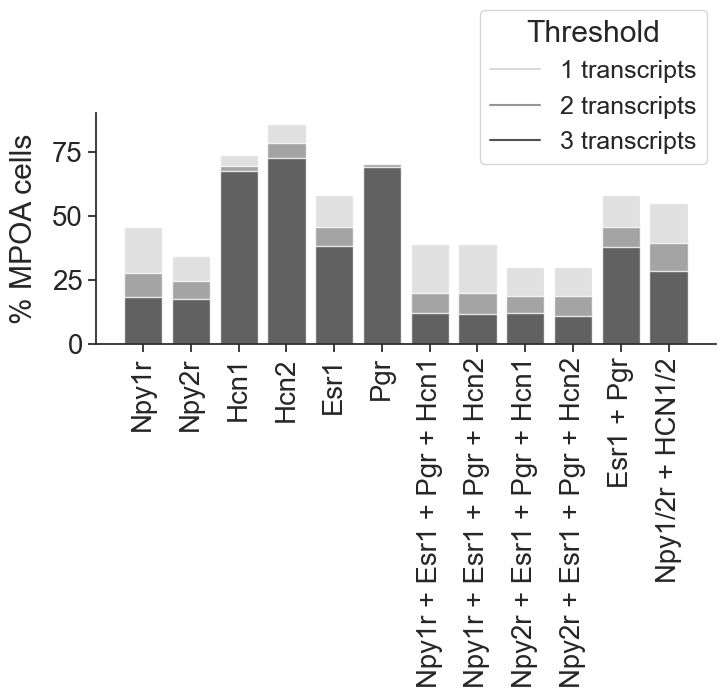

In [24]:
all_percentages = pd.concat([percentages, colocalization_results], ignore_index=True)

plt.subplots(figsize=(8, 3))
plt.bar(
    all_percentages["gene"],
    all_percentages["percentage"],
    color=sns.color_palette("Grays", n_colors=len(thresholds)),
    alpha=0.8,
)
for t in thresholds:
    plt.plot([], [], color=sns.color_palette("Grays", n_colors=len(thresholds))[t-1], label=f"{t} transcripts")
plt.legend(
    title="Threshold",
    bbox_to_anchor=(0.6, 1.5),
    loc="upper left",
    fontsize='small',
)
plt.ylabel("% MPOA cells", labelpad=10)
plt.xticks(rotation = 90)
sns.despine()
plt.savefig("output_figures/colocalization_and_thresholds.pdf", bbox_inches='tight', dpi=300, transparent=True)

In [25]:

from upsetplot import UpSet

def plot_normalized_upset(sets, labels, title=None, figsize=(11, 5), category_order=None):

    all_elements = set().union(*sets)
    matrix = pd.DataFrame(index=list(all_elements))

    for label, s in zip(labels, sets):
        matrix[label] = matrix.index.isin(s)
    
    if category_order:
        matrix = matrix[category_order]

    group_counts = matrix.groupby(labels).size()
    total_counts = filtered_df.to_df().shape[0]
    normalized_counts = group_counts / total_counts *100
    

    # Create a figure with large size
    fig = plt.figure(figsize=figsize)

    # Plot to it — upsetplot will use default axes unless we re-tighten
    upset = UpSet(normalized_counts, show_percentages=True,  sort_categories_by=None)
    upset.plot(fig=fig)

    for ax in fig.axes:
        for txt in ax.texts:
            if '%' in txt.get_text():
                txt.set_fontsize(14)
            
                # You can also adjust position:
                # x, y = txt.get_position()
                # txt.set_position((x, y+0.02))

    if title:
        fig.suptitle(title, y=1.02)

    # Manual layout adjustment that *does* work
    fig.set_size_inches(figsize)  # <-- force figure size again
    plt.ylabel("%MPOA cells", labelpad=10)
    # fig.tight_layout()
    plt.savefig("output_figures/upset_plot.pdf", bbox_inches='tight', dpi=300, transparent=True)
    plt.show()
    


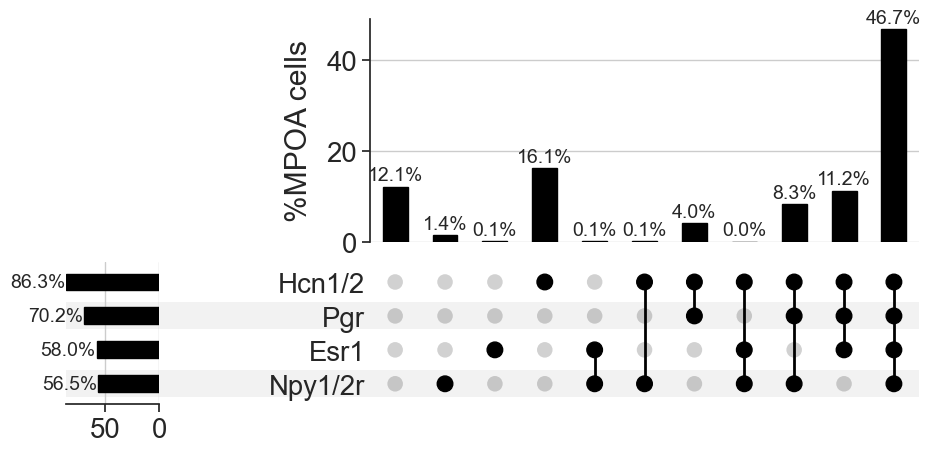

In [69]:
# Create sets
npy1r = set(filtered_df.to_df().copy().loc[:, gene_dict["Npy1r"]][lambda x: x >= 1].index)
npy2r = set(filtered_df.to_df().copy().loc[:, gene_dict["Npy2r"]][lambda x: x >= 1].index)

npyr = npy1r.union(npy2r)
hcn1  = set(filtered_df.to_df().copy().loc[:, gene_dict["Hcn1"]][lambda x: x >= 1].index)
hcn2  = set(filtered_df.to_df().copy().loc[:, gene_dict["Hcn2"]][lambda x: x >= 1].index)
hcn = hcn1.union(hcn2)
esr1 = set(filtered_df.to_df().copy().loc[:, gene_dict["Esr1"]][lambda x: x >= 1].index)
pgr = set(filtered_df.to_df().copy().loc[:, gene_dict["Pgr"]][lambda x: x >= 1].index)
everything_else = set(filtered_df.to_df().copy().index) - npyr - esr1 - pgr - hcn

# Plot
plot_normalized_upset(
    sets=[npyr,  esr1, pgr, hcn, everything_else],
    labels=["Npy1/2r", "Esr1","Pgr", "Hcn1/2"],
    category_order=["Npy1/2r", "Esr1", "Pgr", "Hcn1/2"],
)



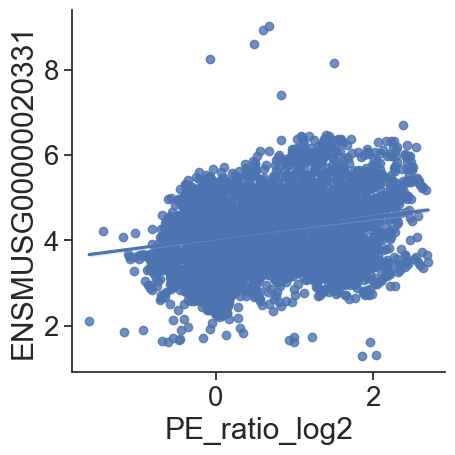

In [137]:
corr_df = filtered_df.to_df()
ensemblr_and = [gene_dict[gene] for gene in and_list]
and_positive = corr_df[(corr_df.loc[:, ensemblr_and] >= 1).all(axis=1)]

and_positive["PE_ratio"] = and_positive[ensemblr_and[1]] / and_positive[ensemblr_and[0]]
and_positive["PE_ratio_log2"] = np.log2(and_positive["PE_ratio"])

gene = "ENSMUSG00000020331"
sns.lmplot(data=and_positive, x="PE_ratio_log2", y=gene)

In [49]:
smf.ols(formula="{} ~ PE_ratio_log2".format(gene), data=and_positive).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:     ENSMUSG00000020331   R-squared:                       0.054
Model:                            OLS   Adj. R-squared:                  0.054
Method:                 Least Squares   F-statistic:                     300.0
Date:                Sun, 29 Jun 2025   Prob (F-statistic):           2.11e-65
Time:                        22:22:49   Log-Likelihood:                -6154.7
No. Observations:                5230   AIC:                         1.231e+04
Df Residuals:                    5228   BIC:                         1.233e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         4.0570      0.013    317.092      0.000       4.032       4.082
PE_ratio_log2     0.2428      0.014     17.321      0.000       0.215       0.270
==============================================================================
Omnibus:                       77.381   Durbin-Watson:                   0.663
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.924
Skew:                           0.169   Prob(JB):                     3.01e-25
Kurtosis:                       3.636   Cond. No.                         1.82
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# Spatial transcriptomics - Langlieb et al. 2023

In [ ]:
# Percentage of neurons positive for Y2 only
test_Y2 = test[((test.Npy2r > 0))]
percent_Y2 = test_Y2.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y2: {percent_Y2:.2f}%")

Percentage of neurons that are Y2: 50.85%


## process and filter region specific data

In [6]:
# Directory where original h5ad files are stored
data_dir = "/Users/caom/Downloads/All_Pucks_h5ad"

# File to store the list of processed filenames
checkpoint_file_path = "/Users/caom/Downloads/processed_filenames.txt"

# Create the checkpoint file if it does not exist
if not os.path.exists(checkpoint_file_path):
    with open(checkpoint_file_path, "w") as f:
        pass  # Just create the file if it doesn't exist

In [7]:
def load_processed_filenames(checkpoint_path):
    with open(checkpoint_path, "r") as file:
        processed_filenames = {line.strip() for line in file}
    return processed_filenames

In [8]:
processed_filenames = load_processed_filenames(checkpoint_file_path)
brain_list = ["MPO", "MPN", "PS", "PD", "ADP"]
filtered_datasets = []

for filename in os.listdir(data_dir):
    if filename.endswith(".h5ad") and filename not in processed_filenames:
        file_path = os.path.join(data_dir, filename)
        adata = sc.read_h5ad(file_path)
        try:
            # Filter the data
            filtered_adata = adata[adata.obs["CCF_acronym"].isin(brain_list)]
            print(adata.obs["CCF_acronym"].unique())
        except Exception as e:
            logging.error(f"Error processing {filename}: {e}")
            with open(checkpoint_file_path, "a") as f:
                f.write(filename + "\n")
            continue

        # Optionally process data and perform operations
        # Here we just check if there's any relevant data
        if filtered_adata.n_obs > 0:
            filtered_datasets.append(filtered_adata)
            # Update the checkpoint file with the filename

        print(f"Processed {filename}")
        with open(checkpoint_file_path, "a") as f:
            f.write(filename + "\n")

['MRN' 'ENTm6' 'NA' 'SCig' 'ENTm5' 'ENTl2' 'SCdw' 'SCdg' 'VISpor5'
 'VISpor2/3' 'VISp5' 'PRNr' 'VISp2/3' 'APr' 'PPN' 'ENTl6a' 'PAG' 'VISpl6a'
 'SUB' 'VISp4' 'NLL' 'ENTm3' 'P' 'VISpl5' 'PG' 'PAR' 'VISp1' 'HPF' 'ENTl5'
 'ENTl3' 'SCiw' 'mcp' 'VISpl4' 'MB' 'RSPd2/3' 'RSPd6a' 'RSPd5' 'Su3'
 'RSPagl2/3' 'VISl2/3' 'VISp6a' 'TRN' 'SCsg' 'ICe' 'SAG' 'rust' 'RSPagl5'
 'ml' 'CS' 'll' 'RSPagl1' 'PRE' 'VISpl2/3' 'SCop' 'VISpor1' 'CLI' 'mlf'
 'tspc' 'RSPd1' 'VISl4' 'sV' 'SCzo' 'RSPagl6a' 'mtg' 'DR' 'VISl1' 'ENTm1'
 'cst' 'bic' 'PBG' 'root' 'scp' 'dscp' 'ENTl1' 'VISpl1' 'ENTm2' 'moV'
 'VISpor6a' 'Pa4' 'AQ' 'CB']
Processed Puck_Num_70.h5ad
['NA' 'CP' 'VL' 'OT' 'MS' 'LSr' 'PIR' 'ACAd2/3' 'ACAv5' 'MOp6a' 'MOp5'
 'SSp-n2/3' 'NDB' 'ACAv2/3' 'ACB' 'GU6a' 'SSp-m5' 'LSc' 'MOs6a' 'STR'
 'ACAd5' 'ACAd1' 'ACAd6a' 'SSs5' 'GU5' 'SSp-ul5' 'MOs1' 'ACAd6b' 'PAL'
 'SSs2/3' 'LSv' 'ACAv6a' 'SSp-ul2/3' 'AId6a' 'ccb' 'AIp5' 'CLA' 'MOs5'
 'MOs2/3' 'SSp-m1' 'SSs6a' 'SSp-m6a' 'SSp-n1' 'SI' 'SSp-m4' 'AIv5'
 'SSp-ul4' 'cing' 

KeyboardInterrupt: 

In [586]:
for filtered_adata in filtered_datasets:
    # original_raw = filtered_adata.raw.copy() if filtered_adata.raw else None

    # # Recreate the raw attribute to reflect the updated var_names
    # filtered_adata.raw = filtered_adata.copy()
    filtered_adata.var_names = filtered_adata.var["features"]

In [589]:
if filtered_datasets:
    all_filtered_data = sc.concat(filtered_datasets, join="outer")
    # all_filtered_data = anndata.concat(filtered_datasets, join='outer')
    logging.info("Concatenated data shape: " + str(all_filtered_data.shape))
    # Save the concatenated data to a file
    all_filtered_data.write_h5ad("/Users/caom/Downloads/final_concatenated_data.h5ad")
else:
    logging.info("No data found with the specified CCF_acronyms.")

## plot summary statistics

In [9]:
data = sc.read_h5ad("/Users/caom/Downloads/final_concatenated_data.h5ad")

In [54]:
def filter_neurons(data, gene_name="Rbfox3", threshold=0.0):
    # Step 1: Check if the gene is in the dataset
    if gene_name not in data.var_names:
        raise ValueError(f"{gene_name} not found in the variable names of the dataset.")

    # Step 2: Get the index of the gene in var_names
    neuron_idx = data.var_names.get_loc(gene_name)

    # Step 3: Create a mask for cells with expression greater than zero
    # Check if the data is stored as a dense or sparse array
    if isinstance(data.X, np.ndarray):
        expressions = data.X[:, neuron_idx]
    else:
        # If the data is stored in a sparse format, convert to dense array to perform the operation
        expressions = data.X[:, neuron_idx].toarray().flatten()

    mask = expressions > 0

    # Step 4: Filter the AnnData object to keep only cells with expression > 0
    neuron_data = data[mask]

    return neuron_data


def filter_by_ccf_acronym(data, acronyms):
    # Check if 'CCF_acronym' is in the observation DataFrame
    if "CCF_acronym" not in data.obs.columns:
        raise ValueError("CCF_acronym is not a column in the .obs DataFrame.")

    # Filter data based on the acronym
    filtered_data = data[data.obs["CCF_acronym"].isin(acronyms)]

    return filtered_data


def filter_by_UMI(data, threshold=500):
    # Check if 'n_counts' is in the observation DataFrame
    if "nCount_Spatial" not in data.obs.columns:
        raise ValueError("n_counts is not a column in the .obs DataFrame.")

    # Filter data based on the threshold
    filtered_data = data[data.obs["nCount_Spatial"] > threshold]

    return filtered_data


# neuron_data = filter_neurons(data, 'Rbfox3')
neuron_data = filter_neurons(data, "Rbfox3", threshold=0)
# neuron_data = filter_neurons(neuron_data, 'Gad1', threshold=0.0)
# neuron_data = filter_by_ccf_acronym(data, ['MPO', 'MPN', 'ADP', 'PS', 'PD'])
neuron_data = filter_by_UMI(data, 500)
# neuron_data = data

In [55]:
print(neuron_data.obs["CCF_acronym"].unique())
# genes_of_interest = ['Npy1r', 'Npy2r', 'Npy4r', 'Npy5r']

['ADP', 'PS', 'MPO', 'MPN']
Categories (4, object): ['ADP', 'MPN', 'MPO', 'PS']


In [56]:
def plot_gene_expression(adata, genes_of_interest):
    # Prepare a DataFrame to hold gene expressions with cells filtered by gene
    # Initialize an empty DataFrame
    plot_data = pd.DataFrame()

    for gene in genes_of_interest:
        if gene in adata.var_names:
            # Check if the data is sparse and convert to a dense array if true
            gene_index = adata.var_names.get_loc(gene)
            if isinstance(adata.X, np.ndarray):
                expressions = adata.X[:, gene_index]
            else:
                expressions = adata.X[:, gene_index].toarray().flatten()

            # Filter expressions greater than zero
            filtered_expressions = expressions[expressions > 0]
            if filtered_expressions.size > 0:
                # Prepare DataFrame for seaborn
                gene_df = pd.DataFrame(
                    {"Expression": filtered_expressions, "Gene": gene}
                )
            else:
                # Include the gene with a NaN entry or placeholder if no cells have expression > 0
                gene_df = pd.DataFrame(
                    {
                        "Expression": [float("nan")],  # Use NaN or another placeholder
                        "Gene": gene,
                    }
                )
        else:
            print(f"Gene {gene} not found in the dataset")

        plot_data = pd.concat([plot_data, gene_df], ignore_index=True)

    # Plotting using seaborn
    plt.figure(figsize=(10, 6))
    sns.violinplot(x="Gene", y="Expression", data=plot_data, palette="Reds")
    sns.stripplot(
        x="Gene", y="Expression", data=plot_data, color="black", size=10, jitter=True
    )
    plt.title("Expression Levels of Genes of Interest")
    sns.despine()
    plt.show()


def plot_percentage_expressed(adata, genes_of_interest, save=False):
    # Create a dataframe to hold the results
    percentage = pd.DataFrame(index=genes_of_interest, columns=["Percentage"])

    # Loop through each gene and calculate the percentage
    for gene in genes_of_interest:
        # Extract the subset for the gene
        subset = adata[:, adata.var_names.isin([gene])]

        # Check if data is sparse and convert to dense if true
        if isinstance(subset.X, np.ndarray):
            more_than = subset.X > 0
        else:
            more_than = (
                subset.X.toarray() > 0
            )  # Ensure compatibility with sparse formats
            # more_than = subset.X > 0

        # Calculate percentage

        percent = np.sum(more_than) / subset.n_obs * 100
        percentage.loc[gene, "Percentage"] = percent

    print(percentage)

    # Plotting
    fig, ax = plt.subplots(figsize=(4, 5))
    sns.set(style="ticks", font_scale=2.5)
    sns.barplot(
        data=percentage.reset_index(), x="index", y="Percentage", palette="Reds"
    )
    plt.ylabel("%Expression", labelpad=10)
    plt.xlabel("")
    plt.xticks([0, 1, 2, 3, 4, 5], ["Y1", "Y2", "Y3", "Y4", "Y5", "Y6"], rotation=45)

    sns.despine()
    if save:
        plt.savefig(
            "/Volumes/lab-kohlj/home/shared/people/Mingran/theis_figure/Figure3/linked_figure3/npyr_expression.pdf",
            dpi=600,
            bbox_inches="tight",
            transparent=True,
        )

    plt.show()


def calculate_coexpression(adata, genes_of_interest, hormone_genes, threshold=0):
    # Initialize a DataFrame to store the results
    results = pd.DataFrame(columns=["Gene", "Coexpression_With_Hormone_Genes (%)"])

    # Create masks for hormone genes expressions
    hormone_mask = adata[:, adata.var_names.isin(hormone_genes)].X > threshold
    if isinstance(hormone_mask, np.ndarray):
        hormone_cells = hormone_mask.any(axis=1)
    else:
        hormone_cells = hormone_mask.toarray().any(axis=1)

    # Iterate through each gene of interest
    for gene in genes_of_interest:
        if gene in adata.var_names:
            # Create a mask for the current gene expression
            gene_mask = adata[:, adata.var_names == gene].X > threshold
            if isinstance(gene_mask, np.ndarray):
                gene_cells = gene_mask.flatten()
            else:
                gene_cells = gene_mask.toarray().flatten()

            # Calculate co-expression
            coexpressed_cells = gene_cells & hormone_cells
            coexpression_percentage = (
                np.sum(coexpressed_cells) / np.sum(gene_cells) * 100
                if np.sum(gene_cells) > 0
                else 0
            )

            # Append results
            results = pd.concat(
                [
                    results,
                    pd.DataFrame(
                        {
                            "Gene": [gene],
                            "Coexpression_With_Hormone_Genes (%)": [
                                coexpression_percentage
                            ],
                        }
                    ),
                ],
                ignore_index=True,
            )

        else:
            # Handle case where gene is not found in the dataset
            print(f"Gene {gene} not found in the dataset")

    # plot the results
    fig, ax = plt.subplots(figsize=(4, 5))
    sns.barplot(
        data=results,
        x="Gene",
        y="Coexpression_With_Hormone_Genes (%)",
        ax=ax,
        palette="Reds",
    )
    sns.despine()
    plt.ylabel("Coexpression (%)")
    plt.xlabel("")
    plt.xticks([0, 1, 2, 3, 4, 5], ["Y1", "Y2", "Y3", "Y4", "Y5", "Y6"], rotation=45)
    plt.show()

    return results

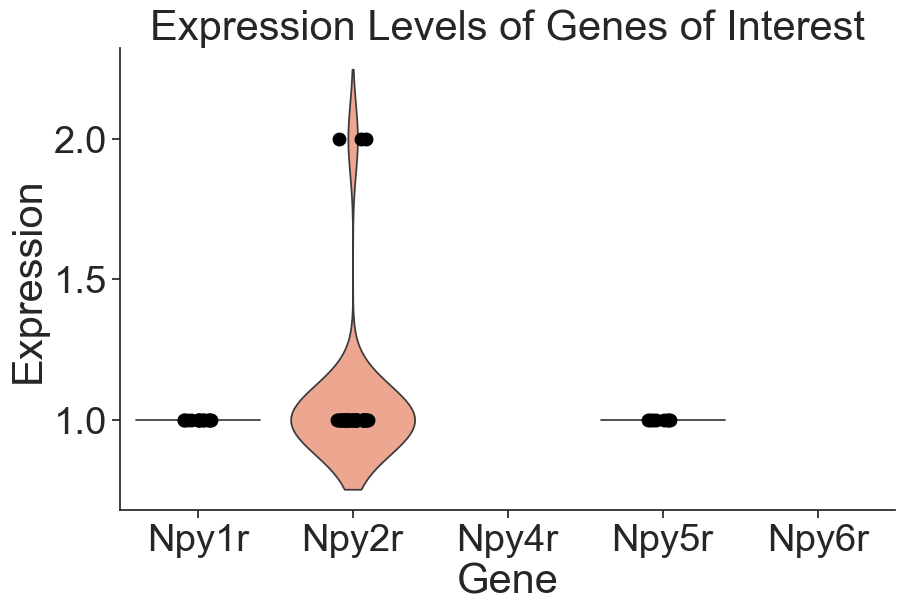

      Percentage
Npy1r   0.581154
Npy2r   1.743462
Npy4r        0.0
Npy5r   0.332088
Npy6r        0.0


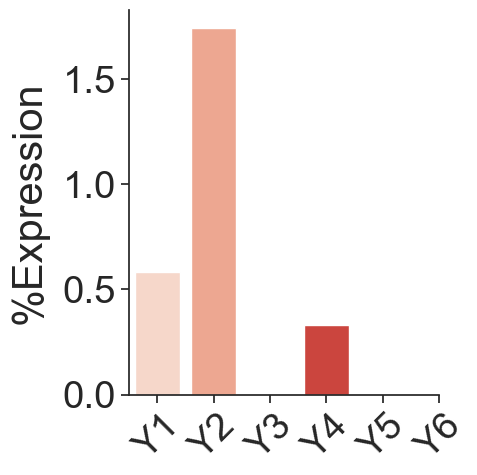

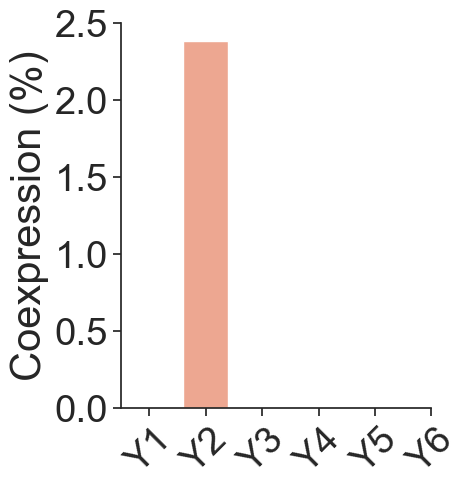

In [57]:
genes_of_interest = ["Npy1r", "Npy2r", "Npy4r", "Npy5r", "Npy6r"]
hormone_genes = ["Esr1", "Pgr"]

non_zero = plot_gene_expression(neuron_data, genes_of_interest)
plot_percentage_expressed(neuron_data, genes_of_interest, save=False)
coexpression = calculate_coexpression(neuron_data, genes_of_interest, hormone_genes)

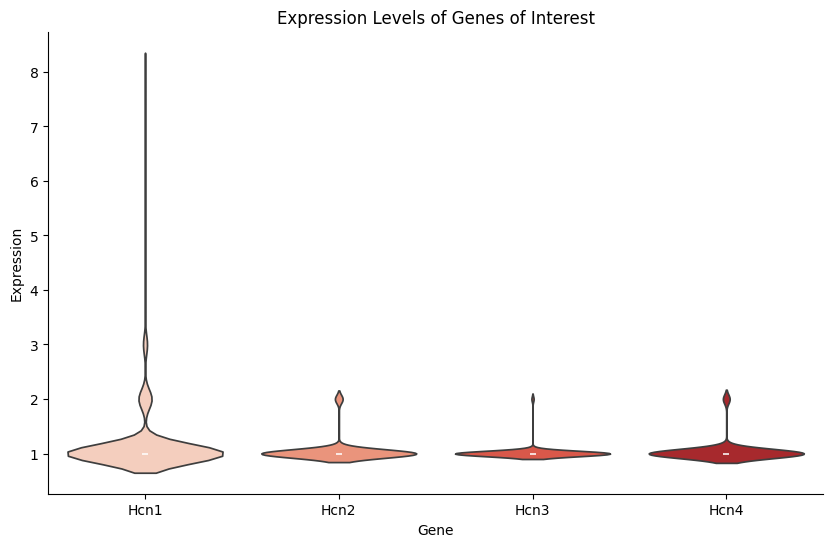

     Percentage
Hcn1   1.612226
Hcn2   0.777229
Hcn3   0.378112
Hcn4   0.378112


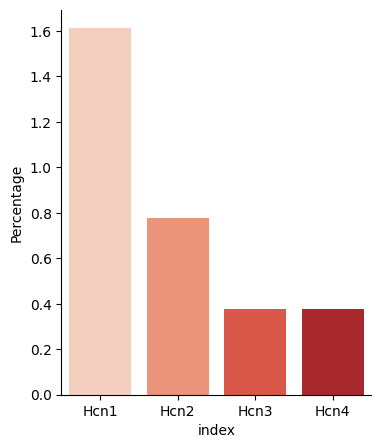

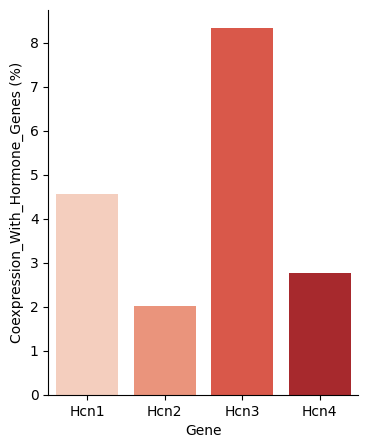

In [25]:
genes_of_interest = ["Hcn1", "Hcn2", "Hcn3", "Hcn4"]
hormone_genes = ["Esr1", "Pgr"]
plot_gene_expression(neuron_data, genes_of_interest)
plot_percentage_expressed(neuron_data, genes_of_interest)
coexpression = calculate_coexpression(neuron_data, genes_of_interest, hormone_genes)

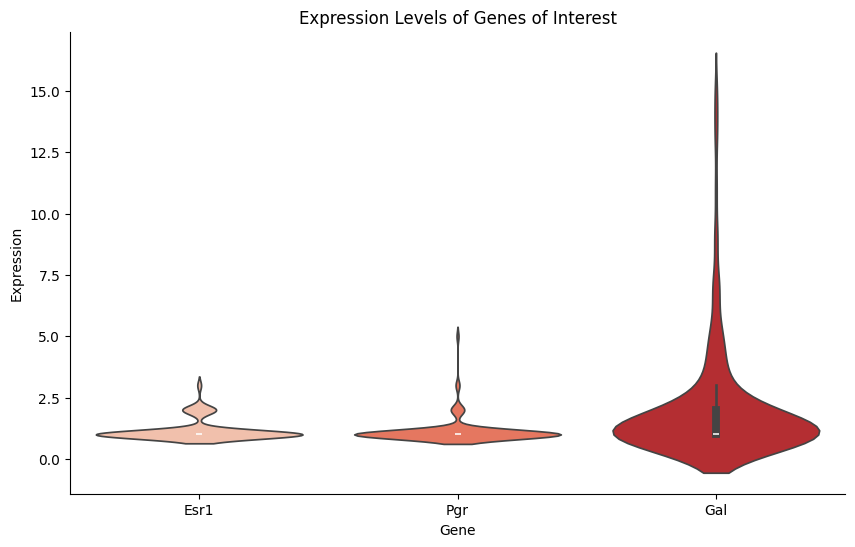

     Percentage
Esr1   0.341351
Pgr    0.614431
Gal    1.003046


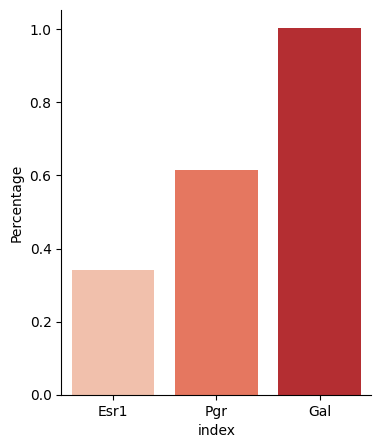

In [636]:
genes_of_interest = ["Esr1", "Pgr", "Gal"]

plot_gene_expression(neuron_data, genes_of_interest)
plot_percentage_expressed(neuron_data, genes_of_interest)

# MERFISH data anaysis

In [14]:
df = pd.read_feather("merfish.feather")

In [15]:
test = df

In [16]:
test["Npyr"] = test.Npy1r + test.Npy2r
print(test[test.Npyr > 0].shape[0] / test.shape[0])

0.6863991562954834


In [17]:
# Percentage of neurons positive for either Y1 or Y2
test_Y = test[((test.Npy1r > 0) | (test.Npy2r > 0))]
percent_Y = test_Y.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are either Y1 or Y2: {percent_Y:.2f}%")

Percentage of neurons that are either Y1 or Y2: 68.64%


In [18]:
# Percentage of neurons positive for Y1 only
test_Y1 = test[((test.Npy1r > 0))]
percent_Y1 = test_Y1.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y1: {percent_Y1:.2f}%")

Percentage of neurons that are Y1: 47.99%


In [18]:
# Percentage of neurons positive for Y2 only
test_Y2 = test[((test.Npy2r > 0))]
percent_Y2 = test_Y2.shape[0] / test.shape[0] * 100
print(f"Percentage of neurons that are Y2: {percent_Y2:.2f}%")

Percentage of neurons that are Y2: 50.85%


In [29]:
# Calculate the percentage of neurons positive for both Esr1 and Npy2r
test_est = test[(test.Esr1 > 0) & (test.Npyr > 0)]
percent_est = test_est.shape[0] / test.shape[0] * 100
print(f"Percentage of npyr+ neurons that are also esr1+: {percent_est:.2f}%")

# Calculate the percentage of neurons positive for both Pgr and Npy2r
test_pgr = test[(test.Pgr > 0) & (test.Npyr > 0)]
percent_pgr = test_pgr.shape[0] / test.shape[0] * 100
print(f"Percentage of npyr+ neurons that are also pgr+: {percent_pgr:.2f}%")

# Combined calculation for either Esr1 or Pgr positive
test_combined = test[((test.Esr1 > 0) & (test.Pgr > 0)) & (test.Npyr > 0)]
percent_combined = test_combined.shape[0] / test.shape[0] * 100
print(
    f"Percentage of npyr+ neurons that are either esr1+ or pgr+: {percent_combined:.2f}%"
)

Percentage of npyr+ neurons that are also esr1+: 23.38%
Percentage of npyr+ neurons that are also pgr+: 31.21%
Percentage of npyr+ neurons that are either esr1+ or pgr+: 15.51%


In [10]:
test_hr = test[
    (test.Esr1 > 0) & (test.Pgr > 0) & (test.Cell_class.isin(["Inhibitory"]))
]
# test_hr = test
test_hr = test_hr.iloc[:, 9:].drop(columns=["Fos"]).dropna()
test_hr["Pgr_esr"] = np.log(test_hr.Pgr / test_hr.Esr1)
test_hr["Npyr"] = test_hr.Npy1r + test_hr.Npy2r
test_hr = test_hr[test_hr.Npyr > 0]
test_hr["Gabra1_log"] = np.log(test_hr["Gabra1"])

/Users/caom/Documents/negative_parental_switch/.conda/lib/python3.11/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


/Users/caom/Documents/negative_parental_switch/.conda/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1563: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a,


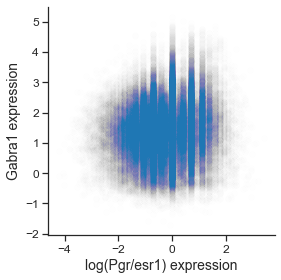

In [11]:
plt.rcParams["figure.figsize"] = 7, 5
sns.set_theme(style="ticks")
sns.lmplot(
    x="Pgr_esr",
    y="Gabra1_log",
    data=test_hr,
    scatter_kws={"alpha": 0.002, "color": "Tab:blue"},
    line_kws={"color": "Tab:blue"},
    height=4,
    aspect=1,
)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("log(Pgr/esr1) expression", fontsize=14)
plt.ylabel("Gabra1 expression", fontsize=14)
plt.savefig("output_figures/Gabra1_corr.png", dpi=300, bbox_inches="tight")
plt.show()

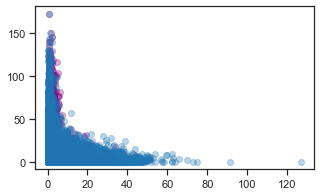

In [8]:
plt.subplots(figsize=(5, 3))
plt.scatter(test_hr.Pgr, test_hr.Gabra1, color="purple", alpha=0.3)
plt.scatter(test_hr.Esr1, test_hr.Gabra1, color="Tab:blue", alpha=0.3)
plt.show()

In [9]:
corr = test_hr.corr().Pgr_esr
display(corr.sort_values())

Esr1         -0.560033
Coch         -0.164719
Scg2         -0.156052
Ar           -0.153568
Ntng1        -0.133731
                ...   
Syt2          0.086817
Gabra1_log    0.114396
Gabra1        0.122658
Pgr           0.264186
Pgr_esr       1.000000
Name: Pgr_esr, Length: 163, dtype: float64

In [10]:
corr = test_hr.corr().Esr1
corr.sort_values()

Pgr_esr      -0.560033
Gabra1_log   -0.183004
Gabra1       -0.179996
Ccnd2        -0.121547
Synpr        -0.107370
                ...   
Coch          0.308312
Scg2          0.345111
Ntng1         0.351045
Pgr           0.446096
Esr1          1.000000
Name: Esr1, Length: 163, dtype: float64